# Explainable AI for Maternal Health Risk Stratification in Kenya
### Predicting Missed Timely Postnatal Care (PNC) — CRISP-DM Notebook

This notebook follows the CRISP-DM methodology end-to-end. Each phase is its own top-level section (`##`) so the whole team works in one file instead of separate notebooks.

**Phases:** 1. Business Understanding · 2. Data Understanding · 3. Data Preparation · 4. Modeling · 5. Evaluation · 6. Deployment

## **Explainable Machine Learning for Predicting Missed Timely Postnatal Care in Kenya**

## 1. Business Understanding

## 1.1 Business Overview

Maternal healthcare is a continuum that includes antenatal care (ANC), delivery care, and postnatal care (PNC). While Kenya has made considerable progress in maternal healthcare utilization, gaps remain in the continuity of care after childbirth.

According to the Kenya Demographic and Health Survey (KDHS) 2022, approximately 98% of women who had a live birth or stillbirth in the two years preceding the survey received ANC from a skilled provider, while about two-thirds attended at least four ANC visits. In addition, 88% of live births occurred in a health facility. However, only 78% of women with a live birth in the two years preceding the survey received a postnatal check within the first two days after birth.

These figures indicate that although contact with the health system is relatively high during pregnancy and delivery, timely postnatal follow-up is not universal. The gap is also uneven across population groups. For example, the KDHS 2022 reports that timely postnatal checks were received by 79% of women in urban areas compared with 69% in rural areas, while coverage ranged from 59% among women in the lowest wealth quintile to 83% among those in the highest wealth quintile.

The availability of detailed maternal-health data from the KDHS 2022 creates an opportunity to use data science to identify characteristics associated with missed timely postnatal care and support more targeted follow-up.

## 1.2  Problem Statement

Despite high utilization of antenatal and facility-based delivery services in Kenya, a proportion of women do not receive a postnatal health check within the first two days after childbirth. Current aggregate statistics describe the size of the gap but do not identify which individual women are more likely to miss timely postnatal care.

Healthcare workers responsible for community-level follow-up may therefore have limited information to prioritize women who could benefit most from additional follow-up.

This project seeks to address this gap by developing an explainable machine-learning model that predicts the likelihood of a woman missing timely postnatal care using demographic, socioeconomic, ANC, delivery, and healthcare-access characteristics from the KDHS 2022 dataset.

The model will not replace healthcare professionals or provide a clinical diagnosis. Instead, it will serve as a decision-support prototype that can help maternal and child health teams identify higher-risk profiles and understand the factors contributing to each prediction.

## 1.3 Business Objective

**Main Objective**

- To develop and deploy an explainable binary classification model that predicts the likelihood of a woman missing timely postnatal care in Kenya and provides understandable explanations for each prediction to support targeted maternal-health follow-up.

**Specific Objectives**


1. *Data Preparation:* To identify, prepare, and engineer relevant demographic, socioeconomic, antenatal care (ANC), delivery, and healthcare-access variables from the KDHS 2022 dataset for predictive modelling.

2. *Predictive Modelling:* To investigate the predictive contribution of demographic, socioeconomic, ANC, delivery, and healthcare-access factors to the likelihood of missing timely postnatal care.

3. *Model Development:* To develop a Logistic Regression model as a baseline and an XGBoost classification model to predict missed timely postnatal care.

4. *Model Evaluation:* To evaluate and compare model performance using PR-AUC as the primary metric, supported by recall, precision, F1-score, ROC-AUC, and confusion-matrix analysis.

5. *Explainable AI:* To apply SHAP-based explainability techniques to identify the key factors contributing to overall model predictions and individual risk predictions.

6. *Decision-Support Prototype:* To develop and deploy an interactive decision-support prototype that generates individual risk predictions and presents the key factors contributing to each prediction.

7. *Geospatial Presentation:* To visualize predicted risk at DHS cluster level using the available GPS data as a presentation layer to support interpretation and potential targeting of maternal-health interventions.

## 1.4 Stakeholders

**Stakeholder	Role / Interest**

- County Ministry of Health MCH Coordinators - Monitor maternal-health outcomes and coordinate targeted interventions

- Community Health Promoters (CHPs) - Conduct community and household follow-up and potentially prioritize women for visits

- Ministry of Health - Use evidence to support maternal-health planning and resource allocation

- Healthcare facilities - Strengthen continuity between ANC, delivery and PNC

- NGOs and development partners - Target maternal-health programmes and resources

- Researchers and public-health analysts - Use evidence to understand factors associated with PNC utilization

- Women and newborns - Ultimate beneficiaries of improved continuity of maternal and newborn care

## 1.5 Metrics of Success

The success of the project will be evaluated at both technical and practical levels.

**Model Performance**

- The primary metric will be PR-AUC, because the project focuses on identifying the minority group of women who miss timely postnatal care.

**Additional metrics will include:**

- Recall — ability to identify women who miss timely PNC
- Precision — proportion of women identified as high risk who actually miss timely PNC
- F1-score — balance between precision and recall
- ROC-AUC — overall discrimination
- Confusion matrix — assessment of classification errors

**Explainability**

- The model should be able to provide meaningful explanations for individual predictions using SHAP, showing the major factors that increase or decrease predicted risk.

**Practical Success**

The final prototype will be considered successful if a user can:

Enter a woman's profile → receive a predicted probability of missing timely PNC → see the risk classification → understand the main factors contributing to the prediction.

## 2. Data Understanding

In [2]:
# Portable setup: read the repository ZIP files directly (no extraction required)
from pathlib import Path
import io
import zipfile

import numpy as np
import pandas as pd
from IPython.display import display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (folder for folder in [cwd, *cwd.parents] if (folder / "data" / "raw" / "KENR8CDT.zip").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/raw/KENR8CDT.zip. Run this notebook from inside the cloned repository."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"
MATERNAL_ZIP = RAW_DIR / "KENR8CDT.zip"
GPS_ZIP = RAW_DIR / "KEGE8AFL.zip"

for archive_path in (MATERNAL_ZIP, GPS_ZIP):
    if not archive_path.exists():
        raise FileNotFoundError(f"Missing required archive: {archive_path.relative_to(PROJECT_ROOT)}")

print(f"Maternal source: {MATERNAL_ZIP.relative_to(PROJECT_ROOT)}")
print(f"GPS source:      {GPS_ZIP.relative_to(PROJECT_ROOT)}")

Maternal source: data\raw\KENR8CDT.zip
GPS source:      data\raw\KEGE8AFL.zip


In [3]:
# Load the pregnancy and postnatal-care recode directly from its ZIP archive.
with zipfile.ZipFile(MATERNAL_ZIP) as archive:
    stata_name = next(name for name in archive.namelist() if name.upper().endswith(".DTA"))
    stata_bytes = io.BytesIO(archive.read(stata_name))

reader = pd.io.stata.StataReader(stata_bytes)
df = reader.read(convert_categoricals=False)
variable_labels = reader.variable_labels()
value_labels = reader.value_labels()

print(f"Loaded: {df.shape[0]:,} records x {df.shape[1]} variables")

Loaded: 13,184 records x 919 variables


In [4]:
# Verify the GPS archive without loading coordinates as model inputs.
with zipfile.ZipFile(GPS_ZIP) as archive:
    gps_shapefile = next(name for name in archive.namelist() if name.upper().endswith(".SHP"))

print(f"Verified GPS file inside ZIP: {gps_shapefile}")
print("GPS coordinates are reserved for mapping and are not model predictors.")

Verified GPS file inside ZIP: KEGE8AFL.shp
GPS coordinates are reserved for mapping and are not model predictors.


## Eligible Population

This recode is **pregnancy-indexed**, not birth-indexed. The eligibility variable is `m80`
("pregnancy outcome for this section"), which flags each woman's most recent pregnancy outcome:

| Code | Meaning |
|---|---|
| 1 | Most recent live birth |
| 3 | Most recent stillbirth |

Filtering to `m80 ∈ {1, 3}` restricts the data to each woman's most recent live birth or stillbirth —
the population this project defines as eligible for postnatal-care risk stratification. Stillbirths
are retained by design: mothers who experience a stillbirth still require postpartum care.

In [5]:
# Full breakdown of ALL pregnancy outcomes in the raw data, before any filtering.
# This shows exactly what gets excluded and why: prior pregnancies and miscarriages/abortions
# are out of scope, since DHS only collects postnatal-care data for a woman's most recent
# pregnancy outcome.
m80_labels = {
    1: "Most recent live birth",
    2: "Prior live birth",
    3: "Most recent stillbirth",
    4: "Prior stillbirth",
    5: "Miscarriage/abortion"
}

outcome_counts = df["m80"].value_counts().sort_index()
outcome_summary = pd.DataFrame({
    "Code": outcome_counts.index,
    "Meaning": [m80_labels.get(c, "Unknown") for c in outcome_counts.index],
    "Count": outcome_counts.values
})
outcome_summary["% of total"] = (outcome_summary["Count"] / len(df) * 100).round(1)

print(f"Total records before filtering: {len(df):,}\n")
print(outcome_summary.to_string(index=False))

Total records before filtering: 13,184

 Code                Meaning  Count  % of total
    1 Most recent live birth  10412        79.0
    2       Prior live birth   1317        10.0
    3 Most recent stillbirth    194         1.5
    4       Prior stillbirth     13         0.1
    5   Miscarriage/abortion   1248         9.5


Applying the `m80 ∈ {1, 3}` filter gives the eligible population, along with a check for any women who appear more than once (multiple "most recent" outcomes recorded across different interview sections).

In [6]:
# Restrict to each woman's most recent live birth (m80=1) or stillbirth (m80=3).
# Stillbirths are retained by design (see markdown above) - mothers still need postpartum care.
eligible = df[df["m80"].isin([1, 3])].copy()

# Breakdown of the eligible population after filtering
print(f"Eligible records (most recent live birth or stillbirth): {eligible.shape[0]:,}")
print(f"Unique women: {eligible['caseid'].nunique():,}")
print(f"Unique survey clusters: {eligible['v001'].nunique():,}")
print()

# Confirm the split between live births and stillbirths within the eligible set
eligible_breakdown = eligible["m80"].value_counts().sort_index()
eligible_summary = pd.DataFrame({
    "Code": eligible_breakdown.index,
    "Meaning": [m80_labels.get(c, "Unknown") for c in eligible_breakdown.index],
    "Count": eligible_breakdown.values
})
eligible_summary["% of eligible"] = (eligible_summary["Count"] / len(eligible) * 100).round(1)

print(eligible_summary.to_string(index=False))
print()

# Note: a woman can appear more than once here if DHS recorded two separate "most recent"
# outcomes for her (e.g. a recent live birth AND a separate recent pregnancy-loss entry).
# We flag this now and resolve it after the target is built (see below), since we need the
# target value to decide which of a woman's records to keep if we ever need to pick one.
duplicate_women = eligible["caseid"].value_counts()
duplicate_women = duplicate_women[duplicate_women > 1]
print(f"Women appearing more than once in the eligible set: {len(duplicate_women)}")

Eligible records (most recent live birth or stillbirth): 10,606
Unique women: 10,540
Unique survey clusters: 1,680

 Code                Meaning  Count  % of eligible
    1 Most recent live birth  10412           98.2
    3 Most recent stillbirth    194            1.8

Women appearing more than once in the eligible set: 66


## Target Variable: Missed Timely Postnatal Care

The mother's postnatal check is captured across two DHS routing paths:
- **Pre-discharge check** (facility path): `m62` (checked, yes/no) → `m63` (timing)
- **Post-discharge / home-delivery check** (catch-all path): `m66` (checked, yes/no) → `m67` (timing)

Timing codes follow the DHS convention: `1XX` = hours, `2XX` = days, `3XX` = weeks, `998` = don't know.

**Target rule** (any provider — matches the standard global PNC-timeliness indicator, which does not
restrict by provider type):
- **0 (timely):** a check occurred within 48 hours on either path (hours `100`–`148`, or days `201`–`202`)
- **1 (missed):** no check occurred on either path, or the earliest check occurred at 3+ days / weeks
- **Excluded:** timing coded `998` (don't know) — only 40 records (0.38%), too small to justify an
  imputation assumption

In [7]:
# Classify each routing path (pre-discharge and post-discharge/home) as timely, late,
# no check occurred, or not applicable - then combine into the final binary target.
def classify_check(check_flag, timing_code):
    if check_flag == 1:
        if pd.isna(timing_code) or timing_code == 998:
            return "unknown"
        elif 100 <= timing_code <= 148 or 201 <= timing_code <= 202:
            return "timely"
        elif timing_code >= 203:
            return "late"
        return "unknown"
    elif check_flag == 0:
        return "no_check"
    return "not_applicable"

def combine_target(pre, post):
    if pre == "timely" or post == "timely":
        return 0
    if pre == "unknown" or post == "unknown":
        return np.nan
    return 1

eligible["pre_discharge_status"] = eligible.apply(lambda r: classify_check(r["m62"], r["m63"]), axis=1)
eligible["post_discharge_status"] = eligible.apply(lambda r: classify_check(r["m66"], r["m67"]), axis=1)
eligible["missed_timely_pnc"] = eligible.apply(
    lambda r: combine_target(r["pre_discharge_status"], r["post_discharge_status"]), axis=1
)

# Exclude the small number of records where timing could not be determined (998/DK)
model_df = eligible[eligible["missed_timely_pnc"].notna()].copy()
model_df["missed_timely_pnc"] = model_df["missed_timely_pnc"].astype(int)

print(f"Final modelling population (before dedup): {model_df.shape[0]:,} records")
print(model_df["missed_timely_pnc"].value_counts(normalize=True).mul(100).round(1))

Final modelling population (before dedup): 10,570 records
missed_timely_pnc
0    74.3
1    25.7
Name: proportion, dtype: float64


### Reconciling the Record Count and Checking for Duplicate Women

Two things to confirm before this becomes the final modelling dataset:
1. Exactly how many records were excluded when building the target, and why.
2. Whether any woman appears more than once (66 were flagged earlier, in the full eligible
   set) - and if so, keep only her most recent pregnancy record, so each woman contributes
   exactly one observation to the model.

In [8]:
# Confirm exactly why the record count drops from 10,606 (eligible) to a smaller number here:
# every record where m63/m67 timing was coded 998 (Don't know) was excluded from the target,
# since we can't safely assign timely/missed without guessing.
n_eligible = eligible.shape[0]
n_unknown = eligible["missed_timely_pnc"].isna().sum()
n_model = model_df.shape[0]

print(f"Eligible population:           {n_eligible:,}")
print(f"Excluded - unknown target (m63/m67 = 998, Don't know): {n_unknown}")
print(f"Modelling population (before dedup): {n_model:,}")
assert n_eligible - n_unknown == n_model, "Numbers don't reconcile - check filtering logic"
print(f"\nConfirmed: {n_eligible:,} - {n_unknown} unknown-target rows = {n_model:,}")

Eligible population:           10,606
Excluded - unknown target (m63/m67 = 998, Don't know): 36
Modelling population (before dedup): 10,570

Confirmed: 10,606 - 36 unknown-target rows = 10,570


In [9]:
# Check for women appearing more than once in the modelling population
dup_counts = model_df["caseid"].value_counts()
dup_women = dup_counts[dup_counts > 1]

print(f"Women appearing more than once: {len(dup_women)}")
print(f"Total records involved: {dup_women.sum()}")

if len(dup_women) > 0:
    # p18 = century day code (cdc) of pregnancy outcome - a precise, sortable chronological
    # value used to determine which of a woman's records is truly the most recent.
    sample = model_df[model_df["caseid"].isin(dup_women.index)][
        ["caseid", "m80", "p1", "p2", "p18", "missed_timely_pnc"]
    ].sort_values(["caseid", "p18"])
    print("\nSample of duplicate records (chronological order via p18):")
    print(sample.head(20))
    print(f"\np18 missing for {sample['p18'].isna().sum()} of these rows")

Women appearing more than once: 65
Total records involved: 130

Sample of duplicate records (chronological order via p18):
               caseid  m80  p1    p2    p18  missed_timely_pnc
37           8  71  2    3   1  2021  44206                  0
36           8  71  2    1  12  2021  44548                  0
119         18  67  2    3   4  2021  44290                  1
118         18  67  2    1   2  2022  44598                  1
305         43  46 15    3   7  2019  43674                  0
304         43  46 15    1  10  2020  44115                  0
712         98   8  6    3   1  2020  43847                  0
711         98   8  6    1   2  2021  44248                  1
861        116  12  2    3   8  2020  44047                  1
860        116  12  2    1   8  2021  44413                  0
1107       136  12  2    3   2  2020  43870                  1
1106       136  12  2    1  11  2021  44503                  1
1155       139  56  2    3   3  2020  43906               

Note: this shows **65** duplicate women here, one fewer than the **66** found earlier in the
full eligible set. That's expected: one of the original 66 had one of her two records excluded
just above (unknown target timing), leaving her with only one record in `model_df` - so she no
longer appears as a "duplicate" at this point, even though she started as one. This is confirmed
explicitly further down.

### Deduplicating to One Record per Woman

Each woman should contribute exactly one observation to the model - both to avoid distorting
the class balance and to prevent the same woman's data leaking across train/test splits later.
For any woman with more than one eligible record, we keep only the most recent pregnancy,
using `p18` (century day code of pregnancy outcome) as the chronological key, with `p2`/`p1`
(year/month of outcome) as a fallback if `p18` is missing for a given row. `p18` is fully
populated for these rows, so no fallback is actually needed here.

In [10]:
import numpy as np

def pregnancy_date_key(row):
    if pd.notna(row.get("p18")):
        return row["p18"]
    if pd.notna(row.get("p2")) and pd.notna(row.get("p1")):
        return row["p2"] * 12 + row["p1"]  # fallback: year*12 + month
    return np.nan

model_df["_date_key"] = model_df.apply(pregnancy_date_key, axis=1)

before_n = model_df.shape[0]
before_women = model_df["caseid"].nunique()

# Keep only the most recent record per woman
model_df = (
    model_df.sort_values("_date_key", ascending=False)
    .drop_duplicates(subset="caseid", keep="first")
    .drop(columns="_date_key")
)

print(f"Before dedup: {before_n:,} records, {before_women:,} unique women")
print(f"After dedup:  {model_df.shape[0]:,} records, {model_df['caseid'].nunique():,} unique women")
print(f"Records dropped: {before_n - model_df.shape[0]}")
print()
print("Final target distribution after dedup:")
print(model_df["missed_timely_pnc"].value_counts(normalize=True).mul(100).round(1))

Before dedup: 10,570 records, 10,505 unique women
After dedup:  10,505 records, 10,505 unique women
Records dropped: 65

Final target distribution after dedup:
missed_timely_pnc
0    74.4
1    25.6
Name: proportion, dtype: float64


### Confirming the Final Unique-Women Count

After deduplication, `model_df` has one record per woman. We'd expect this to match the
10,540 unique women found in the eligible population - let's check.

In [11]:
# %% Confirm final unique-women count against the eligible population's 10,540
print(f"Final unique women in model_df: {model_df['caseid'].nunique():,}")
print(f"Expected (from eligible population): 10,540")
print(f"Difference: {10540 - model_df['caseid'].nunique()} (women who lost both records to unknown-target exclusion)")

Final unique women in model_df: 10,505
Expected (from eligible population): 10,540
Difference: 35 (women who lost both records to unknown-target exclusion)


### Explaining the Gap

The final count is short by 35 women. To confirm why, we check whether the excluded
unknown-target records (36 total) belong to women who had a second, valid record to fall back
on (originally-duplicate women), or to women whose *only* eligible record was excluded outright.

In [12]:
# Identify which unknown-target record belongs to a duplicate woman vs. a single-record woman
# IMPORTANT: use duplicates from the full eligible set (before target exclusion), not model_df,
# since a woman who lost one of her two records to unknown-target exclusion would no longer
# appear as "duplicate" in model_df even though she originally had 2 eligible records.
eligible_dup_counts = eligible["caseid"].value_counts()
eligible_dup_caseids = set(eligible_dup_counts[eligible_dup_counts > 1].index)

unknown_records = eligible[eligible["missed_timely_pnc"].isna()]
unknown_from_dup_women = unknown_records[unknown_records["caseid"].isin(eligible_dup_caseids)]
unknown_from_single_women = unknown_records[~unknown_records["caseid"].isin(eligible_dup_caseids)]

print(f"Unknown-target records from (originally) duplicate women: {len(unknown_from_dup_women)}")
print(f"Unknown-target records from single-record women: {len(unknown_from_single_women)}")

Unknown-target records from (originally) duplicate women: 1
Unknown-target records from single-record women: 35


### Final Modelling Population - Summary

Putting the full chain together:

`13,184` total records → `10,606` eligible (most recent live birth/stillbirth) → `10,570`
after excluding 36 unknown-target records → **`10,505`** after deduplication (65 duplicate
records removed, one row kept per woman).

**Final validated class balance:** 74.4% timely / 25.6% missed timely PNC, across 10,505 women
- each woman contributing exactly one observation.

A stricter "quality PNC" indicator (requiring *all* components of care, not just one qualifying
check) from independent KDHS 2022 analyses sits at 32.7–39% nationally — consistent with our
basic timeliness measure landing meaningfully higher, since it only requires a single check
within 48 hours.

## Candidate Predictors and Missingness

Predictors were mapped from the project proposal to their DHS variable codes, then checked for
missingness across the full eligible population (10,606 records) - independent of target
construction or deduplication, since predictor availability is a property of the raw data itself.

In [13]:
predictor_vars = {
    "v012": "Maternal age", "v106": "Education level", "v501": "Marital status",
    "v714": "Employment status", "v190": "Household wealth", "v201": "Children ever born",
    "m10": "Pregnancy intention", "m14": "Number of ANC visits", "m13": "Timing of first ANC visit",
    "m15": "Place of delivery", "m17": "Caesarean delivery", "v025": "Urban/rural residence",
    "v024": "Region"
}

summary = []
for var, label in predictor_vars.items():
    n_missing = eligible[var].isna().sum()
    summary.append({
        "Variable": var, "Description": label,
        "Missing": n_missing, "Missing %": round(100 * n_missing / len(eligible), 1)
    })

pd.DataFrame(summary)

,Variable,Description,Missing,Missing %
0,v012,Maternal age,0,0.0
1,v106,Education level,0,0.0
2,v501,Marital status,0,0.0
3,v714,Employment status,0,0.0
4,v190,Household wealth,0,0.0
5,v201,Children ever born,0,0.0
6,m10,Pregnancy intention,0,0.0
7,m14,Number of ANC visits,0,0.0
8,m13,Timing of first ANC visit,399,3.8
9,m15,Place of delivery,0,0.0


## Key Findings Summary

1. **Eligible population confirmed:** 10,606 pregnancy records (10,540 women, 1,680 clusters),
   matching the proposal's expected ~10,603.
2. **Target constructed and validated:** 36 records excluded (unknown timing), leaving 10,570
   with a usable target - 74.3% timely / 25.7% missed timely PNC.
3. **Deduplicated to one record per woman:** 65 duplicate records removed (of 66 originally
   identified; the 66th woman had already lost one of her two records to target exclusion),
   leaving **10,505 records - the final modelling population** - at 74.4% timely / 25.6% missed,
   consistent with the pre-dedup split.
4. **Most core predictors are fully populated** (0% missing): age, education, marital status,
   employment, wealth, parity, pregnancy intention, ANC visit count, delivery place, caesarean status,
   residence, region.
5. **Structural gap identified:** healthcare-access-barrier variables (permission/money/distance/going
   alone) were only asked to half the sample (DHS long/short questionnaire split) — excluded from the
   main predictor set, noted as a limitation.
6. **33 unused "country-specific" template columns** (100% missing) identified for removal during
   data preparation.

## 3. Data Preparation and Cleaning

This section converts the validated population from Data Understanding into the final modelling table. It keeps exactly **13 approved predictors and one binary target**. Identifiers, survey-design fields, auditing fields, duplicate geographic representations, and target-source variables are excluded from the exported model inputs.

### 3.1 Start from the validated one-woman table

The preceding section has already applied the eligibility rule, constructed the target, excluded uncertain outcomes, and retained one usable record per woman. We copy that table so cleaning operations do not alter the earlier audit trail.

In [14]:
from pathlib import Path

clean = model_df.copy()

# Locate the repository root so the export works from the root or notebooks folder.
cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (folder for folder in [cwd, *cwd.parents] if (folder / "data" / "raw" / "KENR8CDT.zip").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate data/raw/KENR8CDT.zip. Run this notebook from inside the cloned repository."
    )

print(f"Validated rows entering preparation: {len(clean):,}")
print(f"Unique women: {clean['caseid'].nunique():,}")

Validated rows entering preparation: 10,505
Unique women: 10,505


### 3.2 Clean special codes and create understandable fields

DHS uses numeric codes to store categories. The next cell:

- changes `98 = Don't know` to a true missing value for ANC timing and visits;
- groups detailed delivery places into useful categories;
- adds readable labels for the main categorical predictors.

Missing predictor values are **kept** for now. Imputation should be learned from training data only, after the train/test split, to avoid data leakage.

In [15]:
# Replace DHS special codes with true missing values.
clean["m13"] = clean["m13"].replace({98: np.nan, 99: np.nan})
clean["m14"] = clean["m14"].replace({98: np.nan, 99: np.nan})

education = {0: "No education", 1: "Primary", 2: "Secondary", 3: "Higher"}
marital = {
    0: "Never married", 1: "Married", 2: "Living with partner",
    3: "Widowed", 4: "Divorced", 5: "Separated",
}
wealth = {1: "Poorest", 2: "Poorer", 3: "Middle", 4: "Richer", 5: "Richest"}
yes_no = {0: "No", 1: "Yes"}
residence = {1: "Urban", 2: "Rural"}
intention = {1: "Wanted then", 2: "Wanted later", 3: "Wanted no more"}
county = {
    1: "Mombasa", 2: "Kwale", 3: "Kilifi", 4: "Tana River", 5: "Lamu",
    6: "Taita Taveta", 7: "Garissa", 8: "Wajir", 9: "Mandera", 10: "Marsabit",
    11: "Isiolo", 12: "Meru", 13: "Tharaka-Nithi", 14: "Embu", 15: "Kitui",
    16: "Machakos", 17: "Makueni", 18: "Nyandarua", 19: "Nyeri", 20: "Kirinyaga",
    21: "Murang'a", 22: "Kiambu", 23: "Turkana", 24: "West Pokot", 25: "Samburu",
    26: "Trans Nzoia", 27: "Uasin Gishu", 28: "Elgeyo-Marakwet", 29: "Nandi",
    30: "Baringo", 31: "Laikipia", 32: "Nakuru", 33: "Narok", 34: "Kajiado",
    35: "Kericho", 36: "Bomet", 37: "Kakamega", 38: "Vihiga", 39: "Bungoma",
    40: "Busia", 41: "Siaya", 42: "Kisumu", 43: "Homa Bay", 44: "Migori",
    45: "Kisii", 46: "Nyamira", 47: "Nairobi",
}


def delivery_place_group(code):
    if pd.isna(code):
        return pd.NA
    code = int(code)
    if 10 <= code <= 19:
        return "Home"
    if 20 <= code <= 29:
        return "Public facility"
    if 30 <= code <= 39:
        return "Private facility"
    if 40 <= code <= 49:
        return "Faith-based/NGO facility"
    if code == 96:
        return "Other"
    return pd.NA


model_data = pd.DataFrame({
    "maternal_age": clean["v012"].astype("Int64"),
    "county_name": clean["v024"].map(county),
    "residence": clean["v025"].map(residence),
    "education_level": clean["v106"].map(education),
    "wealth_quintile": clean["v190"].map(wealth),
    "children_ever_born": clean["v201"].astype("Int64"),
    "marital_status": clean["v501"].map(marital),
    "currently_working": clean["v714"].map(yes_no),
    "pregnancy_intention": clean["m10"].map(intention),
    "first_anc_month": clean["m13"].astype("Int64"),
    "anc_visits": clean["m14"].astype("Int64"),
    "delivery_place": clean["m15"].map(delivery_place_group),
    "caesarean_delivery": clean["m17"].map(yes_no),
    "missed_timely_pnc": clean["missed_timely_pnc"].astype("int8"),
})

display(model_data.head())

,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
4239,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3,6,Private facility,Yes,0
11894,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6,3,Private facility,Yes,0
8271,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3,6,Public facility,No,0
9595,33,Kajiado,Rural,Primary,Poorest,5,Married,No,Wanted then,3,6,Home,No,0
5531,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6,4,Public facility,No,1


### 3.3 Create a separate visualization table

The modelling table stays limited to 13 predictors and one target. For charts, maps, and survey-representative summaries, we create a separate table that restores only four useful context fields:

- `cluster_id` for later joins to the displaced DHS mapping file;
- `sample_weight` for representative percentages and rates;
- `county_code` for ordered geographic joins;
- `pregnancy_outcome` for comparing live births and stillbirths.

Woman, household, and respondent identifiers are deliberately excluded because they are unnecessary for visualizations.

In [16]:
visualization_context = pd.DataFrame({
    "cluster_id": clean["v001"].astype("Int64"),
    "sample_weight": clean["v005"] / 1_000_000,
    "county_code": clean["v024"].astype("Int64"),
    "pregnancy_outcome": clean["m80"].map({1: "Live birth", 3: "Stillbirth"}),
})

visualization_data = pd.concat([visualization_context, model_data], axis=1)

assert visualization_data.shape == (len(model_data), 18)
assert visualization_data["sample_weight"].gt(0).all()
assert visualization_data["cluster_id"].notna().all()
assert visualization_data["county_code"].between(1, 47).all()

print(f"Model table:         {model_data.shape[0]:,} rows x {model_data.shape[1]} columns")
print(f"Visualization table: {visualization_data.shape[0]:,} rows x {visualization_data.shape[1]} columns")
display(visualization_data.head())

Model table:         10,505 rows x 14 columns
Visualization table: 10,505 rows x 18 columns


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
4239,480,0.827770,14,Live birth,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3,6,Private facility,Yes,0
11894,1495,0.832490,43,Live birth,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6,3,Private facility,Yes,0
8271,1033,0.471916,30,Live birth,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3,6,Public facility,No,0
9595,1198,1.090190,34,Live birth,33,Kajiado,Rural,Primary,Poorest,5,Married,No,Wanted then,3,6,Home,No,0
5531,722,1.528534,21,Live birth,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6,4,Public facility,No,1


### 3.4 Validate the cleaned table

These checks act like guardrails. If a future file behaves differently, the notebook stops instead of silently producing a questionable dataset.

In [17]:
assert len(model_data) == clean["caseid"].nunique(), "The final table is not one row per woman."
assert model_data.shape[1] == 14, "Expected 13 predictors and one target."
assert model_data["missed_timely_pnc"].isin([0, 1]).all(), "Target contains values other than 0/1."
assert model_data["maternal_age"].between(15, 49).all(), "Maternal age is outside 15–49."
assert model_data["county_name"].notna().all(), "A county code could not be translated."
assert model_data["first_anc_month"].dropna().between(1, 10).all(), "ANC month is implausible."
assert model_data["anc_visits"].dropna().between(0, 20).all(), "ANC visit count is implausible."

target_source_fields = {"m62", "m63", "m66", "m67", "pre_discharge_status", "post_discharge_status"}
assert target_source_fields.isdisjoint(model_data.columns), "Target-source fields leaked into the model table."

non_model_fields = {
    "woman_id", "cluster_id", "household_id", "respondent_line", "sample_weight",
    "county_code", "pregnancy_outcome",
}
assert non_model_fields.isdisjoint(model_data.columns), "A non-model field remains in the export."

validation = pd.DataFrame({
    "check": [
        "Rows in final table", "Unique women", "Columns in final table", "Predictor columns",
        "Missing target values", "Target values", "Target leakage fields", "Non-model fields",
    ],
    "result": [
        f"{len(model_data):,}", f"{clean['caseid'].nunique():,}", model_data.shape[1], model_data.shape[1] - 1,
        model_data["missed_timely_pnc"].isna().sum(),
        sorted(model_data["missed_timely_pnc"].unique().tolist()),
        sorted(target_source_fields.intersection(model_data.columns)),
        sorted(non_model_fields.intersection(model_data.columns)),
    ],
})
display(validation)
print("All validation checks passed.")

,check,result
0,Rows in final table,"10,505"
1,Unique women,"10,505"
2,Columns in final table,14
3,Predictor columns,13
4,Missing target values,0
5,Target values,"[0, 1]"
6,Target leakage fields,[]
7,Non-model fields,[]


All validation checks passed.


### 3.5 Review missing information

This table shows which fields still have blanks after special-code cleaning. Blanks are not automatically errors: for example, ANC timing can be missing when no ANC visit occurred.

We deliberately avoid filling these values here. During modelling, numeric and categorical imputation should be fitted using the training set only.

In [18]:
missing_summary = pd.DataFrame({
    "missing_rows": model_data.isna().sum(),
    "missing_percent": (100 * model_data.isna().mean()).round(2),
}).sort_values(["missing_rows", "missing_percent"], ascending=False)

display(missing_summary.loc[missing_summary["missing_rows"] > 0])

,missing_rows,missing_percent
first_anc_month,397,3.78
anc_visits,10,0.10


### 3.6 Save the model-ready dataset

The final CSV contains only the **13 approved model predictors** and the binary target. Identifiers, survey-design fields, duplicate geographic representations, pregnancy-outcome auditing fields, and raw postnatal routing fields are excluded.

In [19]:
OUTPUT_RELATIVE_PATH = Path("data") / "processed" / "maternal_pnc_model_inputs.csv"
OUTPUT_FILE = PROJECT_ROOT / OUTPUT_RELATIVE_PATH
OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)

try:
    model_data.to_csv(OUTPUT_FILE, index=False)
except PermissionError:
    from datetime import datetime

    fallback_name = f"maternal_pnc_model_inputs_{datetime.now():%Y%m%d_%H%M%S}.csv"
    OUTPUT_RELATIVE_PATH = Path("data") / "processed" / fallback_name
    OUTPUT_FILE = PROJECT_ROOT / OUTPUT_RELATIVE_PATH
    model_data.to_csv(OUTPUT_FILE, index=False)
    print("The standard output file is open in another program, so a timestamped copy was saved instead.")

print(f"Saved {len(model_data):,} rows and {model_data.shape[1]} columns to:")
print(OUTPUT_RELATIVE_PATH.as_posix())

Saved 10,505 rows and 14 columns to:
data/processed/maternal_pnc_model_inputs.csv


### 3.7 Save the visualization dataset

This separate export supports weighted charts and geographic summaries without accidentally expanding the feature matrix used by the model.

In [20]:
VISUALIZATION_RELATIVE_PATH = Path("data") / "processed" / "maternal_pnc_visualization_data.csv"
VISUALIZATION_FILE = PROJECT_ROOT / VISUALIZATION_RELATIVE_PATH

try:
    visualization_data.to_csv(VISUALIZATION_FILE, index=False)
except PermissionError:
    from datetime import datetime

    fallback_name = f"maternal_pnc_visualization_data_{datetime.now():%Y%m%d_%H%M%S}.csv"
    VISUALIZATION_RELATIVE_PATH = Path("data") / "processed" / fallback_name
    VISUALIZATION_FILE = PROJECT_ROOT / VISUALIZATION_RELATIVE_PATH
    visualization_data.to_csv(VISUALIZATION_FILE, index=False)
    print("The standard visualization file is open, so a timestamped copy was saved instead.")

print(f"Saved {len(visualization_data):,} rows and {visualization_data.shape[1]} columns to:")
print(VISUALIZATION_RELATIVE_PATH.as_posix())

Saved 10,505 rows and 18 columns to:
data/processed/maternal_pnc_visualization_data.csv


### 3.8 Cleaning summary

The cleaning flow is now fully reproducible:

1. Load only required fields from the original DHS archive.
2. Keep the most recent live birth or stillbirth records.
3. derive the missed-timely-PNC outcome from both DHS care routes.
4. Exclude only outcomes whose timing cannot be known safely.
5. Keep one usable record per woman.
6. Convert DHS special codes and add readable labels.
7. Validate and export a model-ready table.

The next modelling notebook should split this data into training and test sets **before** learning any imputation, encoding, or scaling rules.

### 3.9 Post-cleaning Exploratory Data Analysis

Exploratory data analysis (EDA) is used here as the final bridge between data preparation and modelling. It examines the cleaned visualization table created in Section 3.3, without reloading a CSV or changing the raw DHS dataframe.

#### Target question

Which characteristics are associated with women missing timely postnatal care (PNC) within two days after childbirth?

#### EDA objectives

- Assess the dataset's structure, quality, and missing values.
- Examine the distribution of missed timely PNC.
- Explore demographic, socioeconomic, pregnancy, and healthcare characteristics.
- Identify factors associated with missing timely PNC.
- Compare missed-PNC rates across counties.
- Examine relationships among the numerical variables.

#### Target variable

- `0` = received timely PNC
- `1` = missed timely PNC

> These results describe relationships in the data. They do not prove that a characteristic causes a woman to miss PNC.

In [21]:
# Prepare the cleaned visualization table for EDA.
# Keep a separate name so the raw DHS dataframe `df` remains unchanged.
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid", palette="deep")

eda_df = visualization_data.copy()
TARGET = "missed_timely_pnc"
target_labels = {0: "Received timely PNC", 1: "Missed timely PNC"}

print(f"EDA dataset: {eda_df.shape[0]:,} rows and {eda_df.shape[1]} columns")
display(eda_df.head())

EDA dataset: 10,505 rows and 18 columns


,cluster_id,sample_weight,county_code,pregnancy_outcome,maternal_age,county_name,residence,education_level,wealth_quintile,children_ever_born,marital_status,currently_working,pregnancy_intention,first_anc_month,anc_visits,delivery_place,caesarean_delivery,missed_timely_pnc
4239,480,0.827770,14,Live birth,38,Embu,Rural,Higher,Richer,3,Married,Yes,Wanted then,3,6,Private facility,Yes,0
11894,1495,0.832490,43,Live birth,23,Homa Bay,Urban,Secondary,Richest,1,Married,Yes,Wanted then,6,3,Private facility,Yes,0
8271,1033,0.471916,30,Live birth,35,Baringo,Rural,Secondary,Poorest,6,Married,No,Wanted then,3,6,Public facility,No,0
9595,1198,1.090190,34,Live birth,33,Kajiado,Rural,Primary,Poorest,5,Married,No,Wanted then,3,6,Home,No,0
5531,722,1.528534,21,Live birth,24,Murang'a,Rural,Higher,Middle,3,Living with partner,No,Wanted later,6,4,Public facility,No,1


In [22]:
# understand the data types of the columns
print("Data types of the columns:")
numeric_columns = [
    "maternal_age",
    "children_ever_born",
    "first_anc_month",
    "anc_visits",
]

categorical_columns = [
    "pregnancy_outcome",
    "county_name",
    "residence",
    "education_level",
    "wealth_quintile",
    "marital_status",
    "currently_working",
    "pregnancy_intention",
    "delivery_place",
    "caesarean_delivery",
]

analysis_only_columns = ["cluster_id", "sample_weight", "county_code"]

print("Numeric predictors:", numeric_columns)
print("Categorical predictors:", categorical_columns)
print("Analysis-only columns:", analysis_only_columns)

display(eda_df[numeric_columns].describe().T)

Data types of the columns:
Numeric predictors: ['maternal_age', 'children_ever_born', 'first_anc_month', 'anc_visits']
Categorical predictors: ['pregnancy_outcome', 'county_name', 'residence', 'education_level', 'wealth_quintile', 'marital_status', 'currently_working', 'pregnancy_intention', 'delivery_place', 'caesarean_delivery']
Analysis-only columns: ['cluster_id', 'sample_weight', 'county_code']


,count,mean,std,min,25%,50%,75%,max
maternal_age,10505.0,28.258924,6.61262,15.0,23.0,27.0,33.0,49.0
children_ever_born,10505.0,3.158401,2.222197,0.0,1.0,3.0,4.0,14.0
first_anc_month,10108.0,4.437178,1.628416,1.0,3.0,4.0,6.0,10.0
anc_visits,10495.0,4.059266,1.820545,0.0,3.0,4.0,5.0,20.0




The cleaned file contains 10,505 observations and a complete binary target. `cluster_id`, `sample_weight`, and `county_code` are useful for analysis, but they are not treated as ordinary model predictors. Exact duplicate rows are not automatically removed because the dataset no longer contains a woman ID; two different women may share the same recorded characteristics.



Missingness is limited to two ANC variables. `first_anc_month` has 397 missing values (3.78%), while `anc_visits` has 10 missing values (0.10%). These values should be handled inside the future modelling pipeline so that information from the test set does not leak into training.

#### 3.9.1 Explore the target variable

To examine how many women received timely PNC and how many missed it.

In [23]:
# Summary of the target variable
target_summary = eda_df[TARGET].value_counts().sort_index().reset_index()
target_summary.columns = [TARGET, "Count"]
target_summary["Outcome"] = target_summary[TARGET].map(target_labels)
target_summary["Percentage"] = (target_summary["Count"] / len(eda_df) * 100).round(1)

display(target_summary[["Outcome", "Count", "Percentage"]]) 

,Outcome,Count,Percentage
0,Received timely PNC,7814,74.4
1,Missed timely PNC,2691,25.6




About 74.4% of women received timely PNC, while 25.6% missed it. The target is moderately imbalanced. A model could obtain high accuracy by mostly predicting the larger class, so later evaluation should include recall, precision, F1-score, and PR-AUC—not accuracy alone.

#### 3.9.2 Univariate analysis of numeric predictors

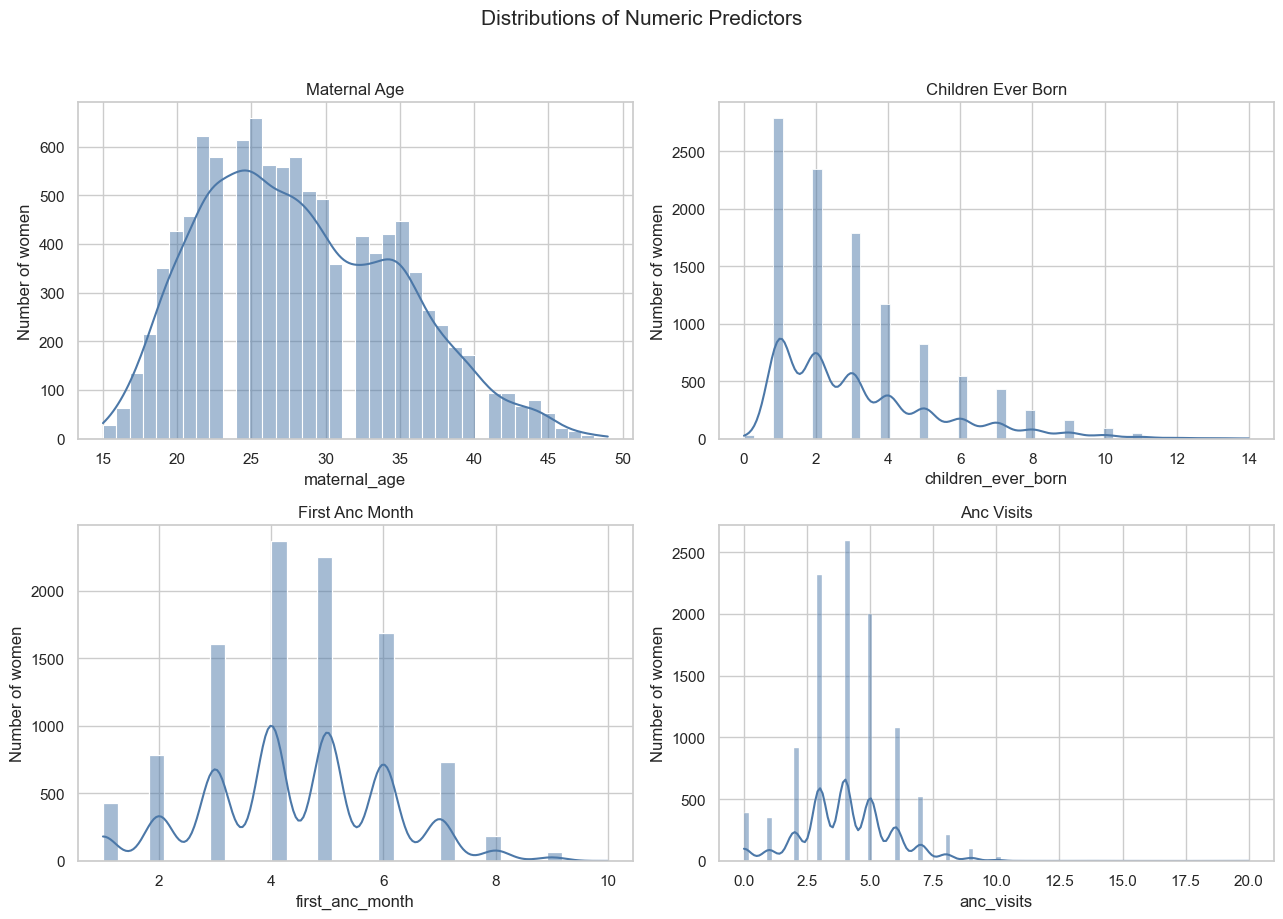

In [24]:
#numeric predictors distribution plots
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for column, axis in zip(numeric_columns, axes.flatten()):
    sns.histplot(data=eda_df, x=column, bins="auto", kde=True, ax=axis, color="#4C78A8")
    axis.set_title(column.replace("_", " ").title())
    axis.set_ylabel("Number of women")

plt.suptitle("Distributions of Numeric Predictors", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



Maternal age is spread across the reproductive age range, while `children_ever_born` is right-skewed because most women have fewer children and a smaller number have high parity. ANC timing is concentrated in the earlier and middle months of pregnancy. ANC visits also show a concentration around commonly recommended attendance levels, with a smaller number of high values.

#### 3.9.3 Numeric predictors compared with the target

Compares the distributions for women who received timely PNC and women who missed it.

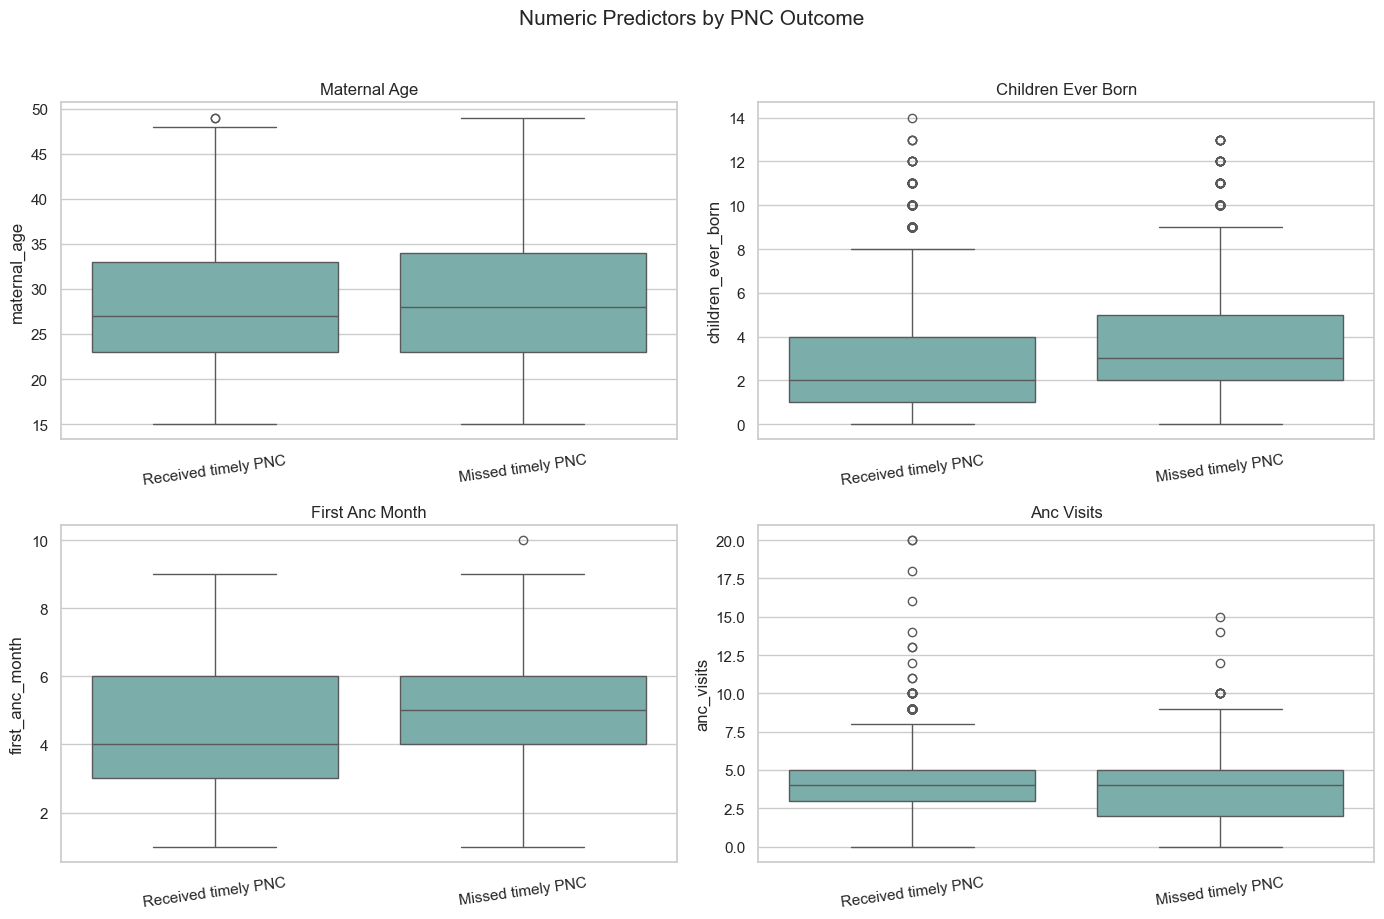

In [25]:
# numeric predictors boxplots by target variable
plot_data = eda_df.copy()
plot_data["PNC outcome"] = plot_data[TARGET].map(target_labels)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for column, axis in zip(numeric_columns, axes.flatten()):
    sns.boxplot(data=plot_data, x="PNC outcome", y=column, ax=axis, color="#72B7B2")
    axis.set_title(column.replace("_", " ").title())
    axis.set_xlabel("")
    axis.tick_params(axis="x", rotation=8)

plt.suptitle("Numeric Predictors by PNC Outcome", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()



The largest visible difference is in ANC visits: women who missed timely PNC generally attended fewer ANC visits. Maternal age and children ever born show more overlap between the two outcome groups. The boxplots suggest useful relationships, but they do not prove that a variable causes missed care.



For categorical predictors, we calculate the percentage who missed timely PNC within each category. This is more useful than comparing raw missed-care counts when category sizes differ.

#### 3.9.4 Categorical predictors

For categorical predictors, we calculate the percentage who missed timely PNC within each category. This is more useful than comparing raw missed-care counts when category sizes differ.

In [26]:
#  Calculate the number of women and the percentage missing timely PNC
def missed_pnc_rate(data, column):
    result = (
        data.groupby(column, observed=False)[TARGET]
        .agg(Women="size", Missed="sum", Missed_rate="mean")
        .reset_index()
    )
    result["Missed_rate_percent"] = result["Missed_rate"] * 100
    return result

##### 3.9.4.1 Delivery place and missed timely PNC

,delivery_place,Women,Missed,Missed_rate_percent
0,Faith-based/NGO facility,528,48,9.1
3,Private facility,1284,158,12.3
4,Public facility,6705,1133,16.9
2,Other,58,24,41.4
1,Home,1930,1328,68.8


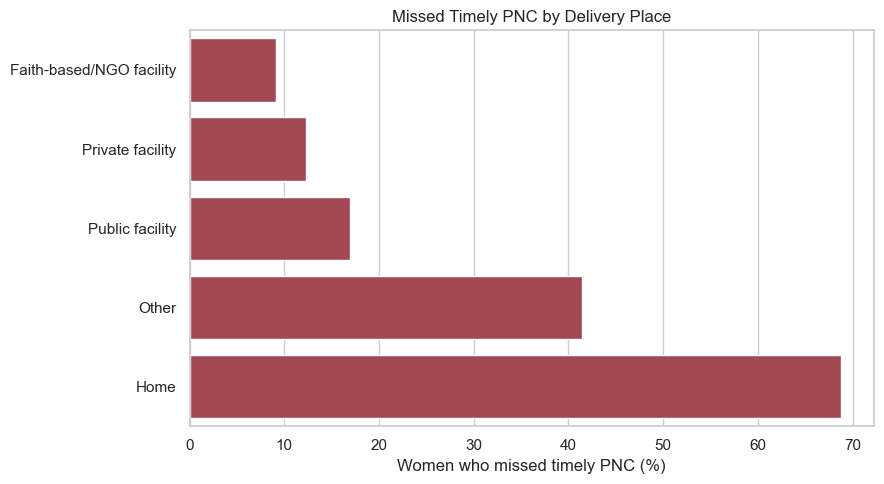

In [27]:
# Missed timely PNC by delivery place
delivery_rates = missed_pnc_rate(eda_df, "delivery_place").sort_values("Missed_rate_percent")
display(delivery_rates[["delivery_place", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(9, 5))
sns.barplot(data=delivery_rates, x="Missed_rate_percent", y="delivery_place", color="#B23A48")
plt.title("Missed Timely PNC by Delivery Place")
plt.xlabel("Women who missed timely PNC (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()



Delivery place shows one of the clearest differences in the EDA. Approximately 68.8% of women who delivered at home missed timely PNC, compared with about 9.1% among women delivering in faith-based or NGO facilities. Delivery place may reflect access, distance, service availability, and the opportunity to receive a check before discharge.

##### 3.9.4.2 Residence and missed timely PNC

,residence,Women,Missed,Missed_rate_percent
0,Rural,6870,2008,29.2
1,Urban,3635,683,18.8


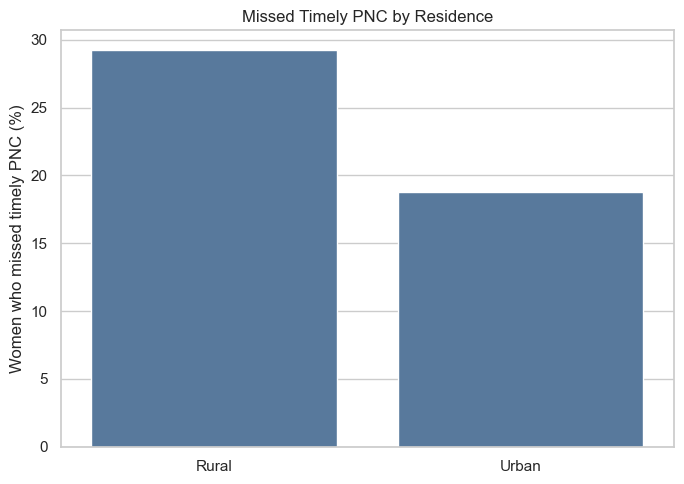

In [28]:
# Missed timely PNC by residence
residence_rates = missed_pnc_rate(eda_df, "residence")
display(residence_rates[["residence", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(7, 5))
ax = sns.barplot(data=residence_rates, x="residence", y="Missed_rate_percent", color="#4C78A8")
plt.title("Missed Timely PNC by Residence")
plt.xlabel("")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()



As observed women in rural areas missed timely PNC as compared to those in urban areas. Any difference may reflect transport, distance to facilities, availability of services, or other socioeconomic factors. Residence should be interpreted alongside county, wealth, education, and delivery place.

##### 3.9.4.3 Education and missed timely PNC

,education_level,Women,Missed,Missed_rate_percent
1,No education,2124,1103,51.9
2,Primary,3548,868,24.5
3,Secondary,3302,549,16.6
0,Higher,1531,171,11.2


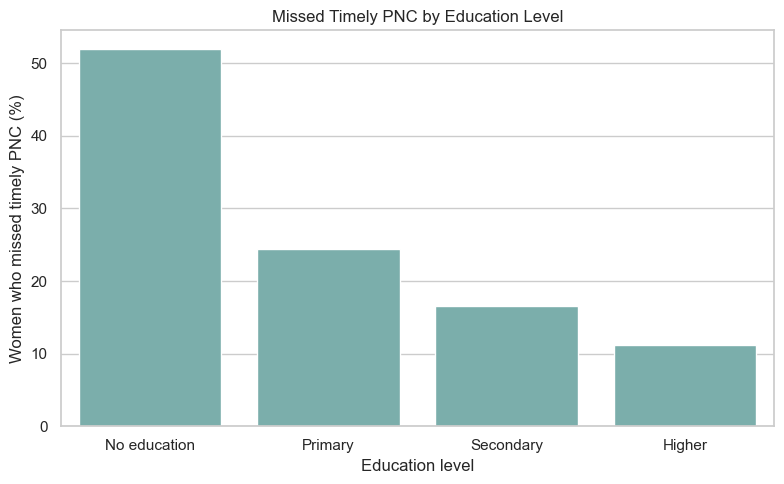

In [29]:
# Missed timely PNC by education level
education_order = ["No education", "Primary", "Secondary", "Higher"]
education_rates = missed_pnc_rate(eda_df, "education_level")
education_rates["education_level"] = pd.Categorical(
    education_rates["education_level"], categories=education_order, ordered=True
)
education_rates = education_rates.sort_values("education_level")
display(education_rates[["education_level", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(8, 5))
sns.barplot(data=education_rates, x="education_level", y="Missed_rate_percent", color="#72B7B2")
plt.title("Missed Timely PNC by Education Level")
plt.xlabel("Education level")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()



Educated women did not miss timely PNC. Education may be related to health information, income, confidence navigating services, and residence. The observed pattern is an association and may overlap with wealth and geography.

##### 3.9.4.4 Wealth and missed timely PNC

,wealth_quintile,Women,Missed,Missed_rate_percent
2,Poorest,3289,1409,42.8
1,Poorer,1775,416,23.4
0,Middle,1841,345,18.7
3,Richer,2064,367,17.8
4,Richest,1536,154,10.0


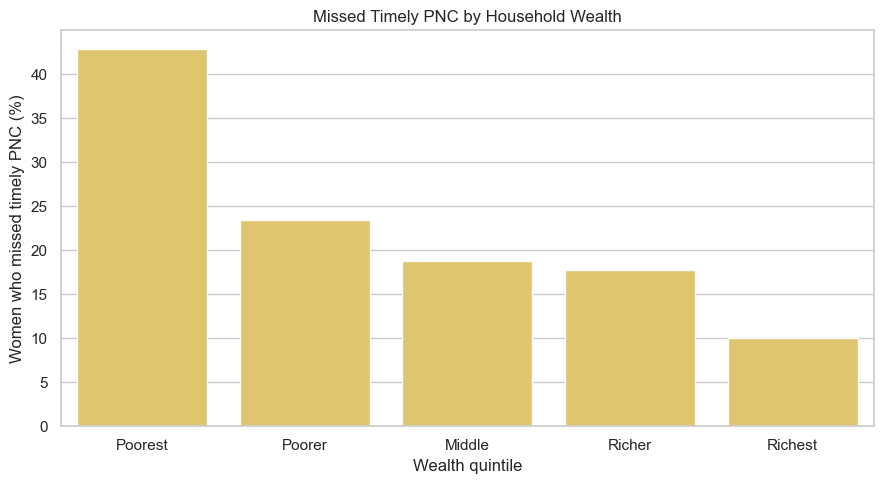

In [30]:
# Missed timely PNC by household wealth
wealth_order = ["Poorest", "Poorer", "Middle", "Richer", "Richest"]
wealth_rates = missed_pnc_rate(eda_df, "wealth_quintile")
wealth_rates["wealth_quintile"] = pd.Categorical(
    wealth_rates["wealth_quintile"], categories=wealth_order, ordered=True
)
wealth_rates = wealth_rates.sort_values("wealth_quintile")
display(wealth_rates[["wealth_quintile", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(9, 5))
sns.barplot(data=wealth_rates, x="wealth_quintile", y="Missed_rate_percent", color="#F2CF5B")
plt.title("Missed Timely PNC by Household Wealth")
plt.xlabel("Wealth quintile")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()



As observed women not considered well of missed timely PNC. Wealth groups can differ in transport options, distance barriers, facility choice, and ability to pay indirect healthcare costs. If missed-PNC rates decline across wealth groups, that would support the idea that access and resources matter. The pattern should still be examined together with residence and education.

##### 3.9.4.5 Pregnancy outcome and missed timely PNC

,pregnancy_outcome,Women,Missed,Missed_rate_percent
0,Live birth,10363,2638,25.5
1,Stillbirth,142,53,37.3


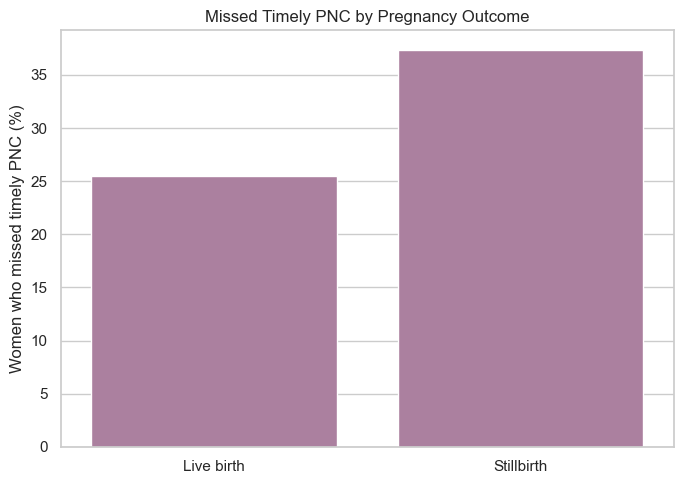

In [31]:
# Missed timely PNC by pregnancy outcome
outcome_rates = missed_pnc_rate(eda_df, "pregnancy_outcome")
display(outcome_rates[["pregnancy_outcome", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(7, 5))
sns.barplot(data=outcome_rates, x="pregnancy_outcome", y="Missed_rate_percent", color="#B279A2")
plt.title("Missed Timely PNC by Pregnancy Outcome")
plt.xlabel("")
plt.ylabel("Women who missed timely PNC (%)")
plt.tight_layout()
plt.show()

Women with stillbirths and live births show different missed-PNC rates, but the stillbirth group is much smaller. 
This comparison includes both live births and stillbirths because mothers require postnatal care after either outcome.

#### 3.9.5 County-level comparison

County has 47 categories, so a horizontal chart is easier to read. We show all counties and retain the sample size in the table.

,county_name,Women,Missed,Missed_rate_percent
14,Kirinyaga,139,10,7.2
3,Busia,244,18,7.4
5,Embu,145,11,7.6
16,Kisumu,244,21,8.6
21,Machakos,157,14,8.9
44,Vihiga,178,16,9.0
33,Nyamira,140,14,10.0
4,Elgeyo-Marakwet,210,22,10.5
18,Kwale,226,24,10.6
12,Kiambu,192,23,12.0


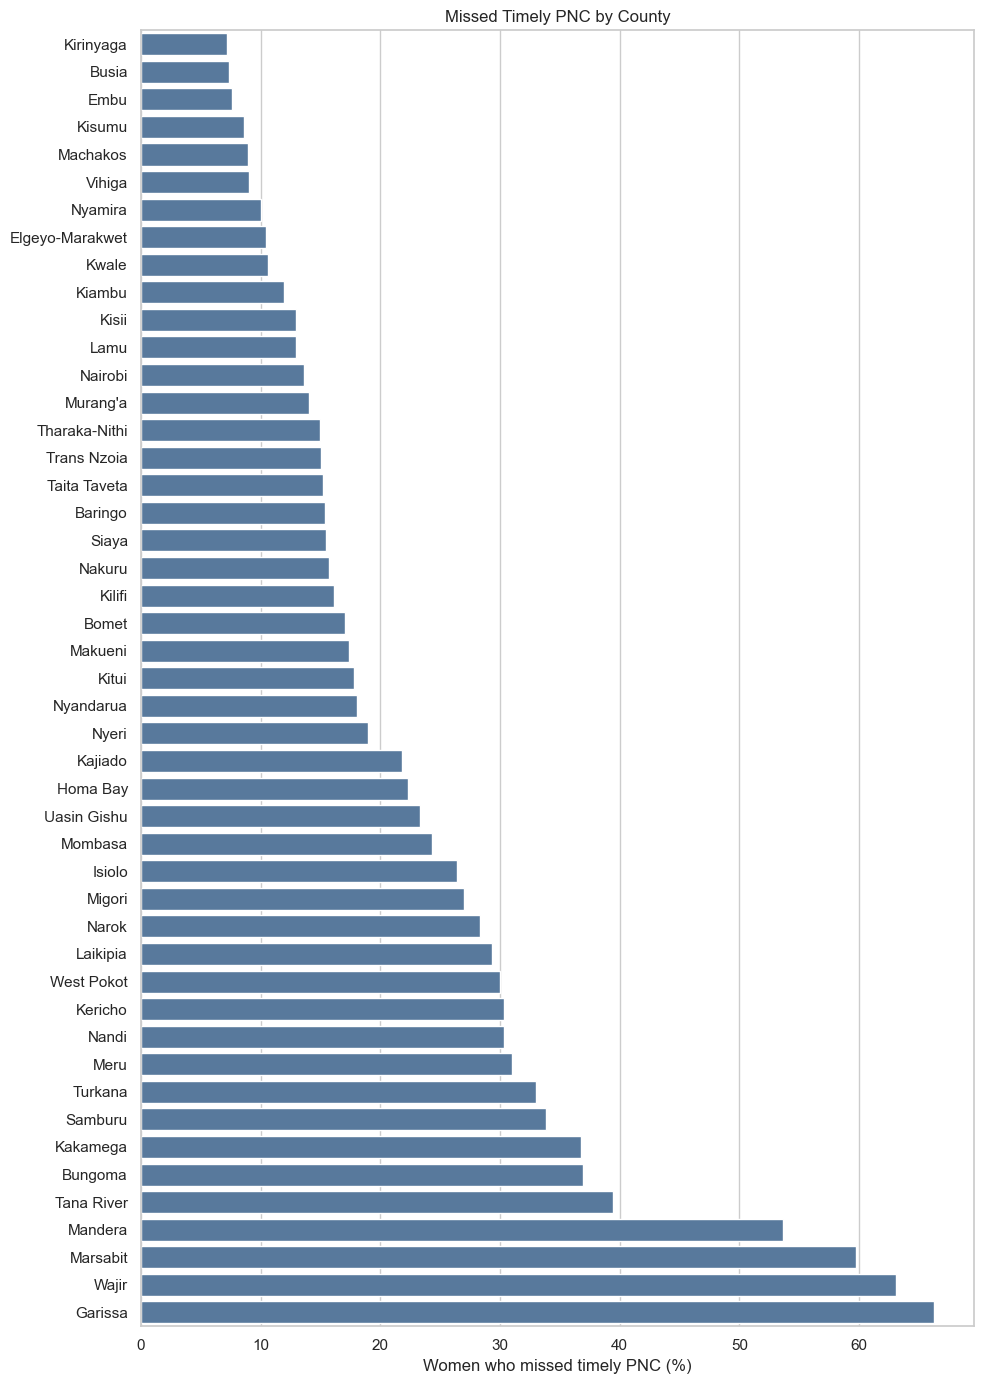

In [32]:
# Missed timely PNC by county
county_rates = missed_pnc_rate(eda_df, "county_name").sort_values("Missed_rate_percent")
display(county_rates[["county_name", "Women", "Missed", "Missed_rate_percent"]].round(1))

plt.figure(figsize=(10, 14))
sns.barplot(data=county_rates, x="Missed_rate_percent", y="county_name", color="#4C78A8")
plt.title("Missed Timely PNC by County")
plt.xlabel("Women who missed timely PNC (%)")
plt.ylabel("")
plt.tight_layout()
plt.show()

Missed timely PNC varies widely by county. Garissa has the highest observed rate, while Kirinyaga has the lowest, suggesting strong geographic differences in access to postnatal care.

#### 3.9.6 Correlation among numeric predictors

The correlation heatmap shows how the numeric predictors move together. Values near `1` indicate a positive relationship, values near `-1` indicate a negative relationship, and values near `0` indicate little linear relationship.

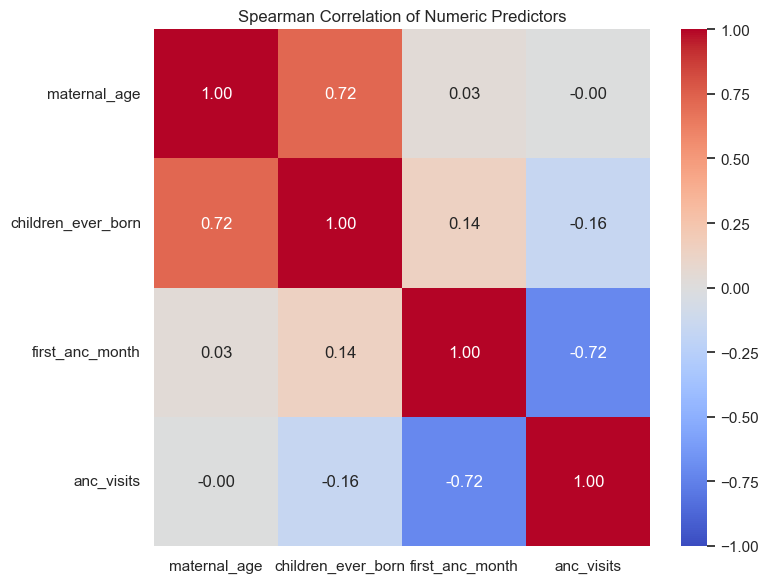

In [33]:
# Spearman correlation matrix of numeric predictors
correlation_matrix = eda_df[numeric_columns].corr(method="spearman")

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Spearman Correlation of Numeric Predictors")
plt.tight_layout()
plt.show()

Maternal age is positively related to the number of children ever born, while starting ANC earlier is generally associated with attending more ANC visits. No correlation is strong enough to suggest removing a variable.

#### 3.9.7 Summary of main findings

1. **The outcome is imbalanced:** 25.6% of the modelling sample missed timely PNC.
2. **The weighted estimate is lower:** approximately 21.5% after applying DHS sample weights.
3. **Delivery place is an important signal:** home delivery has a particularly high missed-care rate.
4. **ANC engagement matters:** women missing timely PNC generally attended fewer ANC visits.
5. **Geography matters:** missed-care rates vary across counties, suggesting local service context is important.
6. **Some predictors overlap:** age relates to number of children, while education, wealth, residence, and county may describe connected aspects of access.


### 3.10 CRISP-DM transition to modelling

The EDA shows moderate target imbalance and highlights delivery place, ANC engagement, residence, wealth, education, pregnancy outcome, and county variation as relevant patterns to test during modelling. The next phase will split the data before preprocessing, build an interpretable baseline, compare it with XGBoost, and evaluate minority-class performance using PR-AUC, recall, precision, and F1-score.

## 4. Modeling

Per the business objectives (1.3), we build two models: a **Logistic Regression baseline** and an **XGBoost classifier**, then compare them. Both are wrapped in a single `sklearn` pipeline together with preprocessing, so imputation, scaling, and encoding are learned from the training fold only — never the test set — exactly as flagged as a requirement back in Section 3.2/3.5.

In [37]:
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve, precision_recall_curve,
)
from xgboost import XGBClassifier

### 4.1 Features and target

We reuse `model_data` from Section 3.6 directly — it already contains exactly the 13 approved predictors and the binary target, with target-leakage fields (`m64`, `m68`–`m81`, etc.) already excluded.

In [38]:
TARGET = "missed_timely_pnc"

numeric_features = ["maternal_age", "children_ever_born", "first_anc_month", "anc_visits"]
categorical_features = [
    "county_name", "residence", "education_level", "wealth_quintile",
    "marital_status", "currently_working", "pregnancy_intention",
    "delivery_place", "caesarean_delivery",
]

X = model_data[numeric_features + categorical_features]
y = model_data[TARGET]

assert set(numeric_features + categorical_features + [TARGET]) == set(model_data.columns), \
    "Feature list does not match model_data's columns."

print(f"X: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"y balance: {y.value_counts(normalize=True).round(3).to_dict()}")

X: 10,505 rows x 13 columns
y balance: {0: 0.744, 1: 0.256}


### 4.2 Train/test split

An 80/20 stratified split, so both sets keep the same ~74/26 class balance. Deduplication in Section 3 already guarantees one row per woman, so there's no risk of the same woman appearing in both sets.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows | missed-PNC rate: {y_train.mean():.3f}")
print(f"Test:  {X_test.shape[0]:,} rows | missed-PNC rate: {y_test.mean():.3f}")

Train: 8,404 rows | missed-PNC rate: 0.256
Test:  2,101 rows | missed-PNC rate: 0.256


### 4.3 Preprocessing pipeline

- **Numeric** (`maternal_age`, `children_ever_born`, `first_anc_month`, `anc_visits`): median imputation (robust to the right-skew in `children_ever_born` seen in the EDA), then standard scaling — scaling doesn't matter for XGBoost but is required for Logistic Regression, and sharing one preprocessor keeps both models on identical inputs.
- **Categorical** (the remaining 9 predictors): most-frequent imputation as a safeguard, then one-hot encoding. In practice only `first_anc_month` and `anc_visits` had missing values in Section 3.5 — the categorical imputer is a no-op on this data but protects against unseen missingness (e.g. in new records through the Streamlit app in Section 6).

This `ColumnTransformer` is not fit yet — it's fit only inside each model's pipeline, on `X_train` alone.

In [40]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

### 4.4 Handling class imbalance

At ~26% positive, imbalance is moderate rather than extreme, so we use built-in class-weighting rather than resampling (e.g. SMOTE), which avoids synthesizing artificial DHS respondents. Both weighting values are computed from `y_train` only:
- Logistic Regression: `class_weight="balanced"`
- XGBoost: `scale_pos_weight` = (negative count / positive count)

In [41]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print(f"Train class counts — negative (timely): {neg:,}, positive (missed): {pos:,}")
print(f"scale_pos_weight: {scale_pos_weight:.3f}")

Train class counts — negative (timely): 6,251, positive (missed): 2,153
scale_pos_weight: 2.903


### 4.5 Baseline: Logistic Regression

The baseline model from the business objectives (1.3) — a simple, inherently interpretable linear model that the XGBoost model needs to beat to justify the added complexity.

In [50]:
log_reg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])

log_reg_pipeline.fit(X_train, y_train)
log_reg_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

print(f"Logistic Regression — PR-AUC: {average_precision_score(y_test, log_reg_proba):.3f}, "
      f"ROC-AUC: {roc_auc_score(y_test, log_reg_proba):.3f}")

Logistic Regression — PR-AUC: 0.618, ROC-AUC: 0.791


### 4.6 Baseline: XGBoost (untuned)

Default hyperparameters, same preprocessing, `scale_pos_weight` from 4.4. This establishes what XGBoost gets "for free" before any tuning, so the tuning step in 4.7 can be judged on its own merit.

In [51]:
xgb_baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )),
])

xgb_baseline_pipeline.fit(X_train, y_train)
xgb_baseline_proba = xgb_baseline_pipeline.predict_proba(X_test)[:, 1]

print(f"XGBoost (untuned) — PR-AUC: {average_precision_score(y_test, xgb_baseline_proba):.3f}, "
      f"ROC-AUC: {roc_auc_score(y_test, xgb_baseline_proba):.3f}")

XGBoost (untuned) — PR-AUC: 0.612, ROC-AUC: 0.774


### 4.7 Hyperparameter tuning (XGBoost)

`RandomizedSearchCV` over the usual XGBoost knobs, scored on **average precision (PR-AUC)** to match the primary metric from 1.5, using 5-fold stratified CV **on the training set only** — the test set stays untouched until final evaluation in Section 5. 30 sampled combinations keeps this to a few minutes on a typical laptop; raise `n_iter` if you want a more exhaustive search.

In [52]:
param_distributions = {
    "classifier__n_estimators": [100, 200, 300, 400],
    "classifier__max_depth": [3, 4, 5, 6, 8],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight": [1, 3, 5, 7],
    "classifier__reg_alpha": [0, 0.01, 0.1, 1],
    "classifier__reg_lambda": [0.5, 1, 1.5, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    xgb_baseline_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, y_train)

print(f"Best CV PR-AUC: {search.best_score_:.3f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k.replace('classifier__', '')}: {v}")

xgb_tuned_pipeline = search.best_estimator_
xgb_tuned_proba = xgb_tuned_pipeline.predict_proba(X_test)[:, 1]

print(f"\nXGBoost (tuned) on held-out test — PR-AUC: {average_precision_score(y_test, xgb_tuned_proba):.3f}, "
      f"ROC-AUC: {roc_auc_score(y_test, xgb_tuned_proba):.3f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best CV PR-AUC: 0.649
Best params:
  subsample: 0.6
  reg_lambda: 2
  reg_alpha: 1
  n_estimators: 400
  min_child_weight: 5
  max_depth: 3
  learning_rate: 0.03
  colsample_bytree: 0.9

XGBoost (tuned) on held-out test — PR-AUC: 0.627, ROC-AUC: 0.790


### 4.8 Modeling summary

Head-to-head comparison of all three model variants on the same held-out test set, before moving to full evaluation in Section 5.

In [53]:
modeling_comparison = pd.DataFrame({
    "Model": ["Logistic Regression (baseline)", "XGBoost (untuned)", "XGBoost (tuned)"],
    "PR-AUC": [
        average_precision_score(y_test, log_reg_proba),
        average_precision_score(y_test, xgb_baseline_proba),
        average_precision_score(y_test, xgb_tuned_proba),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_reg_proba),
        roc_auc_score(y_test, xgb_baseline_proba),
        roc_auc_score(y_test, xgb_tuned_proba),
    ],
}).round(3)

display(modeling_comparison)

,Model,PR-AUC,ROC-AUC
0,Logistic Regression (baseline),0.618,0.791
1,XGBoost (untuned),0.612,0.774
2,XGBoost (tuned),0.627,0.790


## 5. Evaluation

Full evaluation of the final model (tuned XGBoost, `xgb_tuned_pipeline`) against the metrics of success defined in 1.5 — PR-AUC as the primary metric, plus recall, precision, F1, ROC-AUC, and a confusion matrix — followed by SHAP explainability.

### 5.1 Classification metrics at the default threshold

Recall matters most operationally here: a false negative means a woman at real risk of missing PNC is not flagged for community follow-up, while a false positive just means a CHP makes a check-in visit that turns out not to have been necessary. The two costs are not symmetric, which is why PR-AUC (not accuracy) is the primary metric — but it's worth keeping that asymmetry in mind when reading precision/recall below.

In [54]:
def evaluate_at_threshold(y_true, y_proba, threshold=0.5, label="Model"):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "Model": label,
        "Threshold": threshold,
        "PR-AUC": average_precision_score(y_true, y_proba),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

evaluation_summary = pd.DataFrame([
    evaluate_at_threshold(y_test, log_reg_proba, label="Logistic Regression (baseline)"),
    evaluate_at_threshold(y_test, xgb_tuned_proba, label="XGBoost (tuned, final)"),
]).round(3)

display(evaluation_summary)

print("\nClassification report — XGBoost (tuned), threshold 0.5:")
print(classification_report(y_test, (xgb_tuned_proba >= 0.5).astype(int),
                             target_names=["Timely PNC", "Missed timely PNC"]))

,Model,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1
0,Logistic Regression (baseline),0.5,0.618,0.791,0.537,0.656,0.591
1,"XGBoost (tuned, final)",0.5,0.627,0.790,0.590,0.612,0.600



Classification report — XGBoost (tuned), threshold 0.5:
                   precision    recall  f1-score   support

       Timely PNC       0.86      0.85      0.86      1563
Missed timely PNC       0.59      0.61      0.60       538

         accuracy                           0.79      2101
        macro avg       0.73      0.73      0.73      2101
     weighted avg       0.79      0.79      0.79      2101



### 5.2 Threshold selection

0.5 is an arbitrary cutoff carried over from the default. Since the goal is prioritizing CHP follow-up visits rather than a hard yes/no diagnosis, it's worth checking the threshold that maximizes F1 as a reference point — a Streamlit dashboard (Section 6) could ultimately expose this as an adjustable slider rather than a fixed value, since the acceptable trade-off is a program-design decision, not a modelling one.

In [55]:
precisions, recalls, thresholds = precision_recall_curve(y_test, xgb_tuned_proba)
f1_scores = np.divide(
    2 * precisions * recalls, precisions + recalls,
    out=np.zeros_like(precisions), where=(precisions + recalls) != 0,
)
best_idx = np.argmax(f1_scores[:-1])  # last point has no corresponding threshold
best_threshold = thresholds[best_idx]

print(f"F1-optimal threshold: {best_threshold:.3f}")
display(pd.DataFrame([
    evaluate_at_threshold(y_test, xgb_tuned_proba, threshold=0.5, label="XGBoost (tuned), threshold 0.5"),
    evaluate_at_threshold(y_test, xgb_tuned_proba, threshold=best_threshold, label="XGBoost (tuned), F1-optimal threshold"),
]).round(3))

F1-optimal threshold: 0.485


,Model,Threshold,PR-AUC,ROC-AUC,Precision,Recall,F1
0,"XGBoost (tuned), threshold 0.5",0.500,0.627,0.79,0.590,0.612,0.600
1,"XGBoost (tuned), F1-optimal threshold",0.485,0.627,0.79,0.581,0.630,0.605


### 5.3 Confusion matrix

Using the default 0.5 threshold for consistency with 5.1.

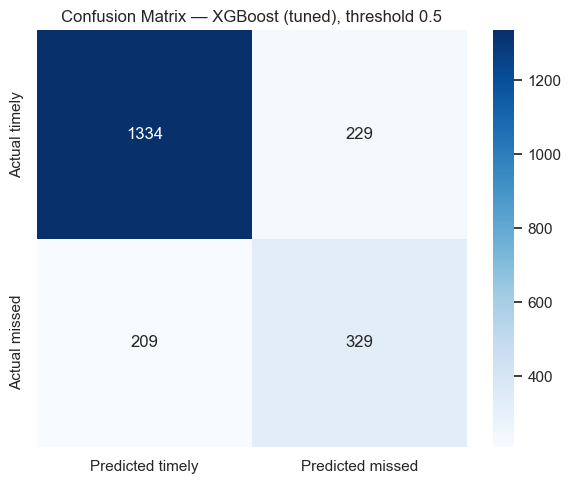

In [56]:
cm = confusion_matrix(y_test, (xgb_tuned_proba >= 0.5).astype(int))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Predicted timely", "Predicted missed"],
    yticklabels=["Actual timely", "Actual missed"],
)
plt.title("Confusion Matrix — XGBoost (tuned), threshold 0.5")
plt.ylabel("")
plt.xlabel("")
plt.tight_layout()
plt.show()

### 5.4 ROC and Precision-Recall curves

Comparing the tuned XGBoost model against the Logistic Regression baseline.

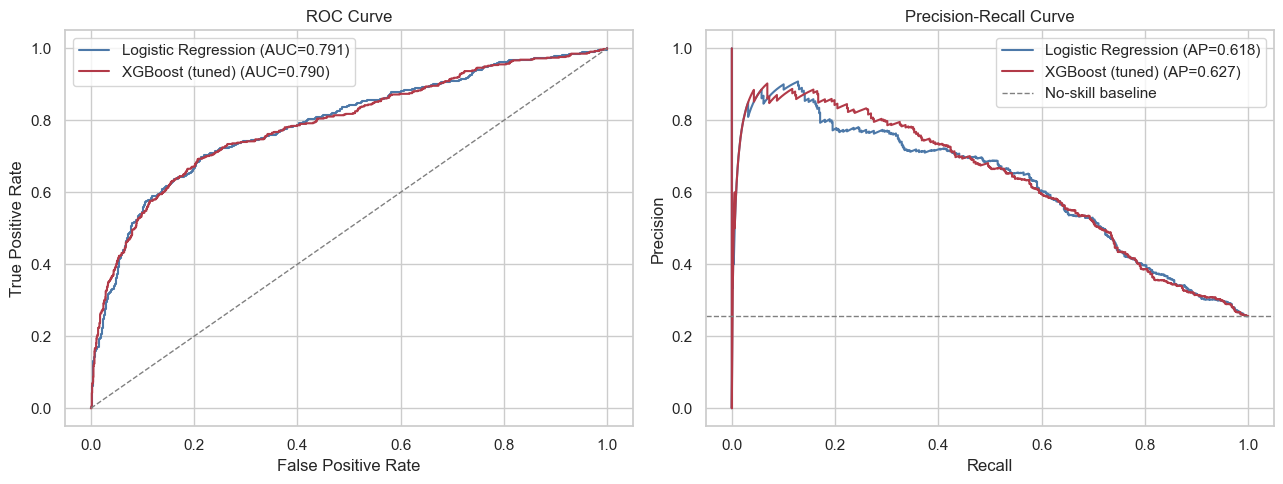

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for proba, label, color in [
    (log_reg_proba, "Logistic Regression", "#4C78A8"),
    (xgb_tuned_proba, "XGBoost (tuned)", "#B23A48"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{label} (AUC={roc_auc_score(y_test, proba):.3f})", color=color)

    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{label} (AP={average_precision_score(y_test, proba):.3f})", color=color)

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", linewidth=1)
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].axhline(y_test.mean(), linestyle="--", color="grey", linewidth=1, label="No-skill baseline")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.5 SHAP: global explainability

This is the core deliverable for the project's "explainable AI" framing (1.3): not just *which* women are flagged as high-risk, but *why*, in terms Ministry of Health coordinators and CHPs can act on.

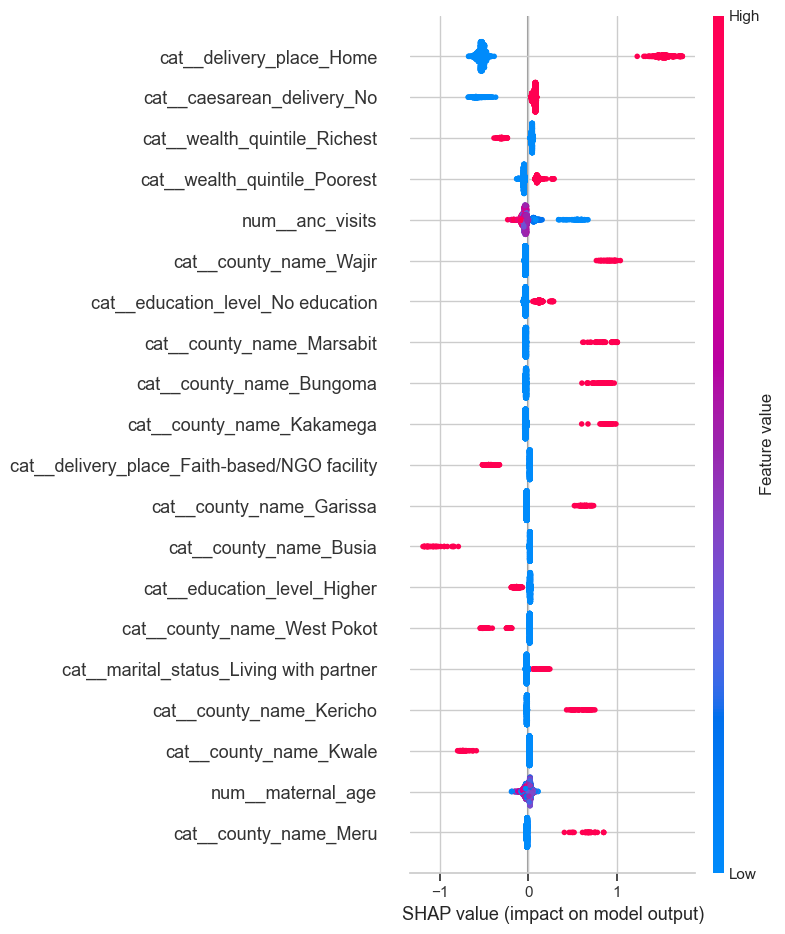

In [58]:
import shap

xgb_model = xgb_tuned_pipeline.named_steps["classifier"]
fitted_preprocessor = xgb_tuned_pipeline.named_steps["preprocessor"]

X_test_transformed = fitted_preprocessor.transform(X_test)
feature_names = fitted_preprocessor.get_feature_names_out()

explainer = shap.TreeExplainer(xgb_model)
shap_explanation = explainer(X_test_transformed)
shap_explanation.feature_names = list(feature_names)

shap.summary_plot(shap_explanation, X_test_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

Mean absolute SHAP value per feature — overall importance, independent of direction.

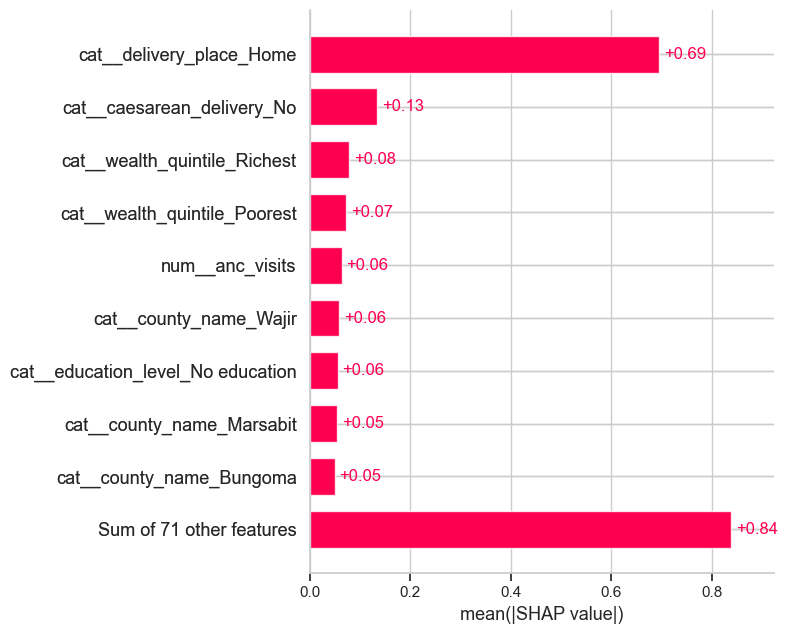

In [59]:
shap.plots.bar(shap_explanation, show=False)
plt.tight_layout()
plt.show()

### 5.6 SHAP: local explainability

Two individual examples from the test set: the woman the model is most confident is at risk, and one it's most confident is not — the kind of per-woman breakdown a CHP-facing tool would show.

Highest predicted risk: 0.969 (actual label: 0)


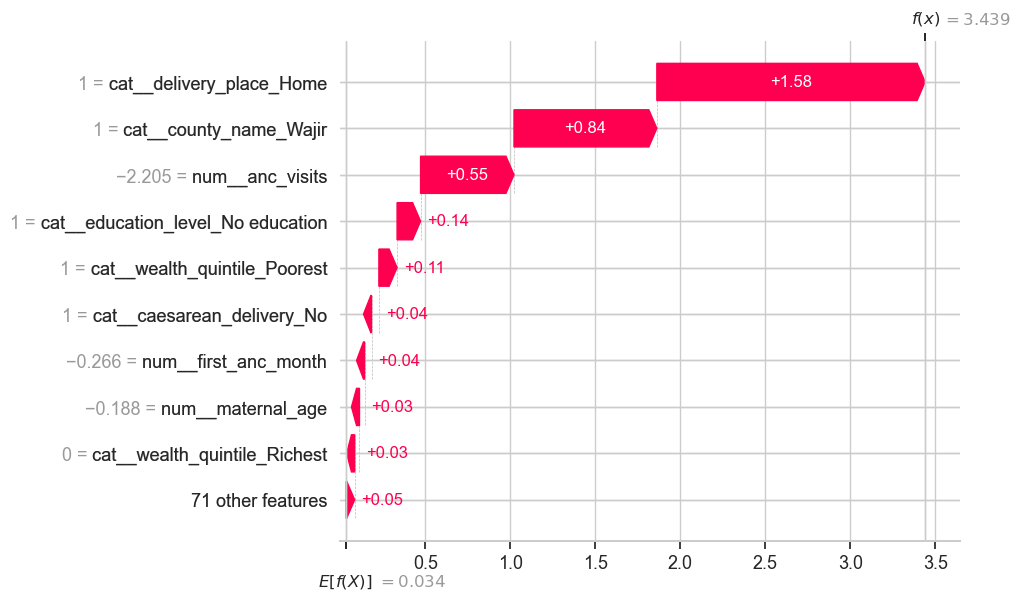

In [60]:
highest_risk_idx = int(np.argmax(xgb_tuned_proba))
lowest_risk_idx = int(np.argmin(xgb_tuned_proba))

print(f"Highest predicted risk: {xgb_tuned_proba[highest_risk_idx]:.3f} "
      f"(actual label: {y_test.iloc[highest_risk_idx]})")
shap.plots.waterfall(shap_explanation[highest_risk_idx], show=False)
plt.show()

Lowest predicted risk: 0.034 (actual label: 0)


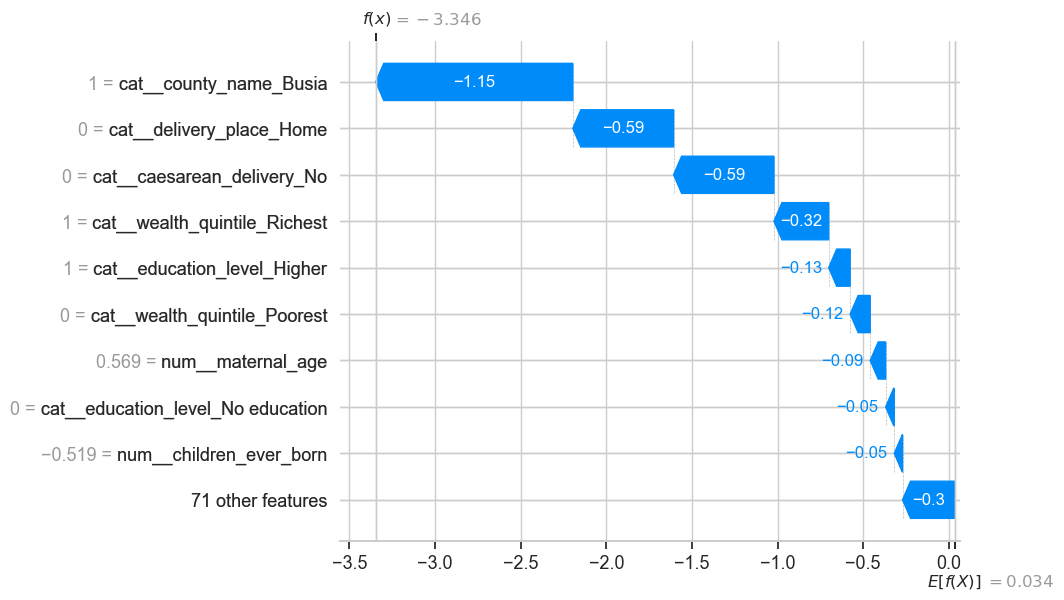

In [61]:
print(f"Lowest predicted risk: {xgb_tuned_proba[lowest_risk_idx]:.3f} "
      f"(actual label: {y_test.iloc[lowest_risk_idx]})")
shap.plots.waterfall(shap_explanation[lowest_risk_idx], show=False)
plt.show()

### 5.7 Evaluation summary

- **Final model:** tuned XGBoost (`xgb_tuned_pipeline`), selected on PR-AUC per the primary metric in 1.5.
- **Threshold:** 0.5 by default; 5.2 shows an F1-optimal alternative, but the operational threshold is ultimately a program-design choice for MOH/CHP stakeholders, not a fixed modelling output.
- **Explainability:** SHAP global importance (5.5) and per-woman waterfall breakdowns (5.6) directly support the project's core goal — giving CHPs an understandable reason behind each risk flag, not just a score.
- **Next step:** Section 6 (Deployment) wraps `xgb_tuned_pipeline` and the SHAP explainer into the Streamlit app.

## 6. Deployment

*(Streamlit app — see `/app`.)*

In [36]:
# TODO: link/summary of Streamlit deployment